librarys
-------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

load data and check it
----------

In [4]:
df=pd.read_csv("diabetes.csv")

In [5]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


idenify relationships with representation
-----------

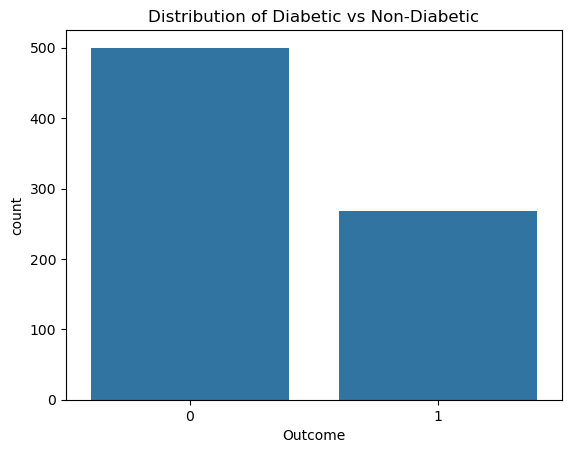

In [11]:
sns.countplot(x="Outcome", data=df)
plt.title("Distribution of Diabetic vs Non-Diabetic")
plt.show()

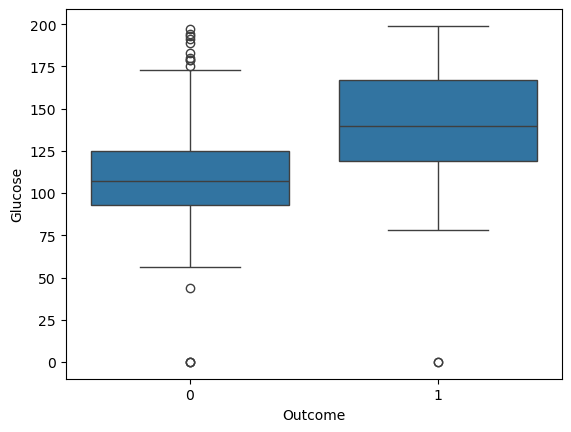

In [12]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()

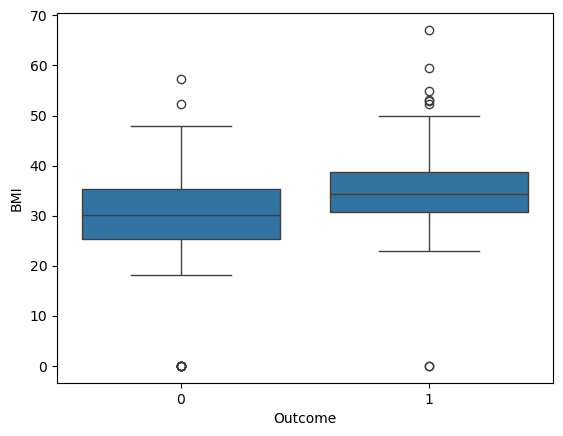

In [13]:
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.show()

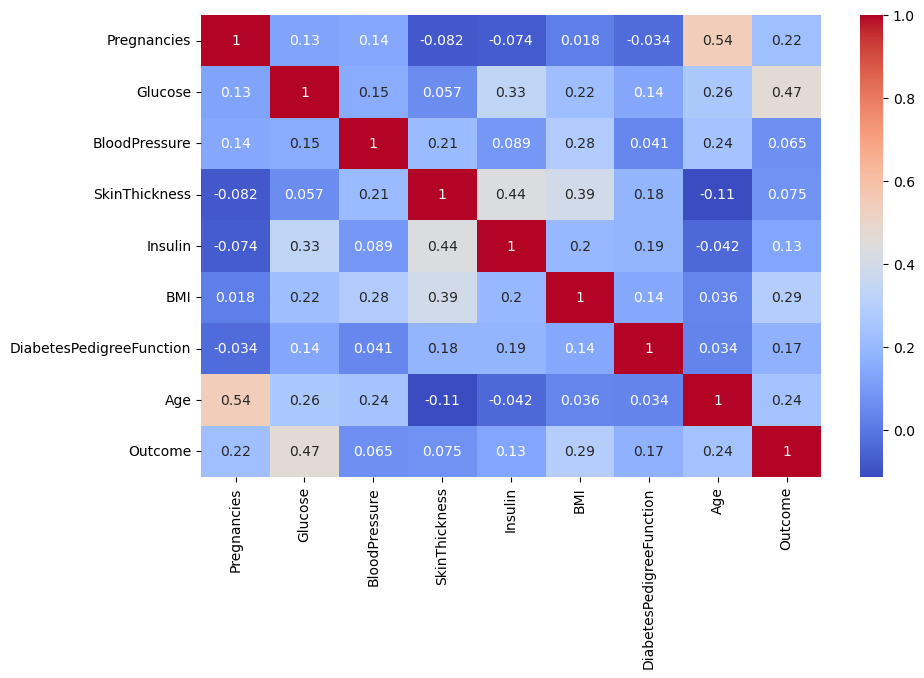

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

prepare data and spilt it to used in models
------------

In [16]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale data

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classification model
--

Logistic Regression

In [22]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7532467532467533
[[79 20]
 [18 37]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



svm classification

In [67]:
param_grid_svm = {
    "C": [0.01, 0.1, 1, 10, 100,1000],   
    "kernel": ["linear", "rbf"]     
}

# Initialize SVM
svm = SVC(probability=True, random_state=42)

# GridSearchCV
grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=6,              
    scoring="accuracy",# Metric to optimize
    n_jobs=-1          # Use all cores
)

# Fit on training data (scaled)
grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters for SVM:", grid_svm.best_params_)
print("Best Cross-Validation Accuracy:", grid_svm.best_score_)

Best Parameters for SVM: {'C': 1, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.768656006091757


In [65]:
best_svm = grid_svm.best_estimator_

# Predict
y_pred_svm = best_svm.predict(X_test_scaled)

print("Test Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Test Accuracy (SVM): 0.7337662337662337

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


Confusion Matrix:
 [[82 17]
 [24 31]]


----------------

RandomForest

In [25]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7207792207792207
[[77 22]
 [21 34]]
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



used GridSearch with two model
----

In [27]:
param_grid_log = {"C":[0.01, 0.1, 1, 10, 100]}
grid_log = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_log, cv=5)
grid_log.fit(X_train_scaled, y_train)
print("Best Logistic Regression Params:", grid_log.best_params_)
print("Best Score:", grid_log.best_score_)

Best Logistic Regression Params: {'C': 10}
Best Score: 0.7655071304811408


In [28]:
param_grid_rf = {"n_estimators":[50,100,200], "max_depth":[None,5,10,20]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)
print("Best Random Forest Params:", grid_rf.best_params_)
print("Best Score:", grid_rf.best_score_)

Best Random Forest Params: {'max_depth': None, 'n_estimators': 50}
Best Score: 0.7769025723044115


test models with diffrent data 
---------

In [30]:
def predict_patient(model, scaler):
    """
    Predict the probability of being Diabetic based on user input.
    """

    # Define acceptable ranges for each feature
    ranges = {
        "Pregnancies": (0, 20),
        "Glucose": (0, 300),
        "BloodPressure": (0, 200),
        "SkinThickness": (0, 100),
        "Insulin": (0, 900),
        "BMI": (0, 70),
        "DiabetesPedigreeFunction": (0, 3),
        "Age": (0, 120)
    }

    # Collect patient input
    patient_data = []
    for feature, (low, high) in ranges.items():
        value = float(input(f"Enter {feature} ({low}-{high}): "))
        if not (low <= value <= high):
            print(f"Warning: {feature} = {value} is outside the expected range [{low}, {high}]")
        patient_data.append(value)

    # Convert to DataFrame with same column names
    columns = list(ranges.keys())
    patient_df = pd.DataFrame([patient_data], columns=columns)

    # Scale input
    patient_scaled = scaler.transform(patient_df)

    # Predict probability of being diabetic
    prob = model.predict_proba(patient_scaled)[0][1]
    print(f"\nDiabetes Probability: {prob:.4f} ({prob*100:.2f}%)")

    return prob

predict_patient(log_reg, scaler)

Enter Pregnancies (0-20):  19
Enter Glucose (0-300):  150
Enter BloodPressure (0-200):  150
Enter SkinThickness (0-100):  80
Enter Insulin (0-900):  500
Enter BMI (0-70):  60
Enter DiabetesPedigreeFunction (0-3):  1
Enter Age (0-120):  80



Diabetes Probability: 0.9873 (98.73%)


0.9872668990465494

In [31]:
def predict_patient(model, scaler):
    """
    Predict the probability of being Diabetic based on user input.
    """

    # Define acceptable ranges for each feature
    ranges = {
        "Pregnancies": (0, 20),
        "Glucose": (0, 300),
        "BloodPressure": (0, 200),
        "SkinThickness": (0, 100),
        "Insulin": (0, 900),
        "BMI": (0, 70),
        "DiabetesPedigreeFunction": (0, 3),
        "Age": (0, 120)
    }

    # Collect patient input
    patient_data = []
    for feature, (low, high) in ranges.items():
        value = float(input(f"Enter {feature} ({low}-{high}): "))
        if not (low <= value <= high):
            print(f"Warning: {feature} = {value} is outside the expected range [{low}, {high}]")
        patient_data.append(value)

    # Convert to DataFrame with same column names
    columns = list(ranges.keys())
    patient_df = pd.DataFrame([patient_data], columns=columns)

    # Scale input
    patient_scaled = scaler.transform(patient_df)

    # Predict probability of being diabetic
    prob = model.predict_proba(patient_scaled)[0][1]
    print(f"\nDiabetes Probability: {prob:.4f} ({prob*100:.2f}%)")

    return prob

predict_patient(rf, scaler)

Enter Pregnancies (0-20):  15
Enter Glucose (0-300):  150
Enter BloodPressure (0-200):  150
Enter SkinThickness (0-100):  80
Enter Insulin (0-900):  700
Enter BMI (0-70):  60
Enter DiabetesPedigreeFunction (0-3):  2
Enter Age (0-120):  70



Diabetes Probability: 0.2000 (20.00%)


C:\Users\ELOott\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.2

In [61]:
def predict_patient(model, scaler):
    """
    Predict the probability of being Diabetic based on user input.
    """

    # Define acceptable ranges for each feature
    ranges = {
        "Pregnancies": (0, 20),
        "Glucose": (0, 300),
        "BloodPressure": (0, 200),
        "SkinThickness": (0, 100),
        "Insulin": (0, 900),
        "BMI": (0, 70),
        "DiabetesPedigreeFunction": (0, 3),
        "Age": (0, 120)
    }

    # Collect patient input
    patient_data = []
    for feature, (low, high) in ranges.items():
        value = float(input(f"Enter {feature} ({low}-{high}): "))
        if not (low <= value <= high):
            print(f"Warning: {feature} = {value} is outside the expected range [{low}, {high}]")
        patient_data.append(value)

    # Convert to DataFrame with same column names
    columns = list(ranges.keys())
    patient_df = pd.DataFrame([patient_data], columns=columns)

    # Scale input
    patient_scaled = scaler.transform(patient_df)

    # Predict probability of being diabetic
    prob = model.predict_proba(patient_scaled)[0][1]
    print(f"\nDiabetes Probability: {prob:.4f} ({prob*100:.2f}%)")

    return prob

predict_patient(best_svm, scaler)

Enter Pregnancies (0-20):  18
Enter Glucose (0-300):  200
Enter BloodPressure (0-200):  150
Enter SkinThickness (0-100):  90
Enter Insulin (0-900):  500
Enter BMI (0-70):  60
Enter DiabetesPedigreeFunction (0-3):  1
Enter Age (0-120):  17



Diabetes Probability: 0.4360 (43.60%)


0.4360167923785031